# **Human Pose Estimation with YOLO11 Using the OpenThermalPose2 Dataset**

This notebook presents a complete pipeline for **human pose estimation**, where the [YOLO-pose](https://docs.ultralytics.com/tasks/pose/#models) model is fine-tuned using the [OpenThermalPose2](https://d197for5662m48.cloudfront.net/documents/publicationstatus/228303/preprint_pdf/cbfbd66133e72b81e470beeed5c079c4.pdf) dataset.

The **YOLO-pose** model was originally pretrained on the [COCO-Pose](https://cocodataset.org/#keypoints-2017) dataset, which is designed for human pose estimation with **17 annotated keypoints** per person. **COCO-Pose** contains 56,599 training images, 2,346 validation images, and 20,288 test images (with test annotations not publicly available). Its large scale and diversity make it a strong foundation for general-purpose pose estimation tasks.

The **OpenThermalPose2** dataset is an extension of [OpenThermalPose](https://d197for5662m48.cloudfront.net/documents/publicationstatus/202871/preprint_pdf/3672814f9015b66c20293ff029fdd2db.pdf), also incorporating images from the [TFW](https://github.com/IS2AI/TFW) dataset. It contains 11,931 grayscale thermal images of 170 different individuals and 21,125 annotated human instances, following the same keypoint format as **COCO-Pose** (17 per person). **OpenThermalPose2** covers a variety of scenarios, including fitness exercises, multi-person activities, people seated indoors, and people walking outdoors under different weather conditions. The dataset is split into 8,846 training images, 934 validation images, and 2,151 test images.

## **Imports**

In [1]:
# Installation of the Ultralytics library
!pip install ultralytics==8.3.192 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from PIL import Image
from google.colab import drive
from dataclasses import dataclass
from glob import glob
from IPython.display import display, Video
import subprocess
import yaml
import cv2
import os

# Necessary in Colab with Ultralytics to prevent path-related encoding errors
import locale
locale.getpreferredencoding = lambda: "UTF-8"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Mount Google Drive in Colab
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


## **Configuration**

In [ ]:
@dataclass()
class Config():
    """
    Configuration class for training the YOLO-pose model on the OpenThermalPose2 dataset.
    Centralizes paths, hyperparameters, and training options.
    """
    model_name   : str   = "yolo11l-pose.pt"
    data_zip_path: str   = "/content/drive/MyDrive/Datasets/OpenThermalPose2.zip"
    data_dir     : str   = "otp2_dataset"
    project_dir  : str   = "/content/drive/MyDrive/Ultralytics"

    resume       : bool  = True
    epochs       : int   = 100
    batch_size   : int   = 16
    imgsz        : int   = 640
    patience     : int   = 7
    close_mosaic : int   = 10

    optimizer    : str   = "AdamW"
    lr0          : float = 1e-4
    lrf          : float = 1e-2
    momentum     : float = 0.9

config = Config()
config.project_name = os.path.join(config.project_dir, "HumanPoseEstimation_YOLO11l_OpenThermalPose2")

## **Dataset Preparation**

The images and annotations of the **OpenThermalPose2** dataset are available for download from its [official GitHub repository](https://github.com/IS2AI/OpenThermalPose). The dataset is already provided in the **YOLO-pose** format, so no additional preprocessing is required. However, some inconsistencies were found: in several images, the bounding boxes exceed the image dimensions, and in one instance, two keypoints with a visibility value greater than 0 also fall outside the corresponding image boundaries. Therefore, these anomalies had to be corrected before fine-tuning the **YOLO-pose** model.

In [ ]:
# Unzip the original dataset
!unzip -q {config.data_zip_path}

In [ ]:
for split in {"train", "val", "test"}:
    # Iterate through all label files for each dataset split
    for path in tqdm(glob(os.path.join(config.data_dir, f"{split}/labels/*.txt"))):
        labels = np.loadtxt(path, np.float32, ndmin=2)
        new_labels = []

        for label in labels:
            # Extract YOLO bounding box (x_center, y_center, width, height)
            x_center, y_center, w, h = label[1:5]
            xmin = x_center - (w / 2)
            ymin = y_center - (h / 2)
            xmax = x_center + (w / 2)
            ymax = y_center + (h / 2)

            # Clip bounding boxes that go outside image boundaries
            if (xmin < 0) or (ymin < 0) or (xmax > 1) or (ymax > 1):
                xmin, ymin, xmax, ymax = np.clip([xmin, ymin, xmax, ymax], 0, 1)
                x_center = (xmin + xmax) / 2
                y_center = (ymin + ymax) / 2
                w = xmax - xmin
                h = ymax - ymin
            
            # Mask keypoints outside image boundaries instead of discarding the sample
            kpts = label[5:].reshape(-1, 3)
            mask = (kpts[:, 2] > 0) & np.any((kpts[:, :2] < 0) | (kpts[:, :2] > 1), axis=1)
            if np.any(mask):
                kpts[mask] = 0

            new_labels.append([0, x_center, y_center, w, h] + kpts.flatten().tolist())
        
        # Overwrite the file with corrected labels
        os.remove(path)
        with open(path, "w") as f:
            f.writelines(" ".join(map(str, row)) + "\n" for row in new_labels)

100%|██████████| 8846/8846 [00:03<00:00, 2234.77it/s]


In [ ]:
# Number of images and labels after preprocessing
print(
    len(os.listdir(os.path.join(config.data_dir, "train/images"))),
    len(os.listdir(os.path.join(config.data_dir, "train/labels")))
)

print(
    len(os.listdir(os.path.join(config.data_dir, "val/images"))),
    len(os.listdir(os.path.join(config.data_dir, "val/labels")))
)

print(
    len(os.listdir(os.path.join(config.data_dir, "test/images"))),
    len(os.listdir(os.path.join(config.data_dir, "test/labels")))
)

8846 8846
934 934
2151 2151


Finally, it is necessary to create the YAML files for fine-tuning the **YOLO-pose** model. These files must include the paths to the training, validation, and test sets, as well as a list named **flip_idx**, used for random horizontal flipping during data augmentation. This list specifies the IDs of symmetric keypoints that should be swapped during the flip, while asymmetric ones remain unchanged. The **flip_idx** list is essential for applying random horizontal flipping within Ultralytics’ data augmentation pipeline. In addition, the keypoint dimensions for each instance (**kpt_shape**) must be specified, which in this case is `[17, 3]`, the same as in **COCO-Pose**.

In [ ]:
skeleton = {
    0: "nose",
    1: "left_eye",
    2: "right_eye",
    3: "left_ear",
    4: "right_ear",
    5: "left_shoulder",
    6: "right_shoulder",
    7: "left_elbow",
    8: "right_elbow",
    9: "left_wrist",
    10: "right_wrist",
    11: "left_hip",
    12: "right_hip",
    13: "left_knee",
    14: "right_knee",
    15: "left_ankle",
    16: "right_ankle"
}

nkpts = len(skeleton)
symmetric_kpts = [[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12], [13, 14], [15, 16]]

flip_idx = np.arange(nkpts)
for pair in symmetric_kpts:
    flip_idx[pair] = flip_idx[pair[::-1]]

flip_idx

array([ 0,  2,  1,  4,  3,  6,  5,  8,  7, 10,  9, 12, 11, 14, 13, 16, 15])

In [ ]:
# Create and save the YAML files with the dataset metadata
metadata = {
    "path": f"../{config.data_dir}",
    "train": "train/images",
    "val": "val/images",

    "kpt_shape": [nkpts, 3],
    "flip_idx": flip_idx.tolist(),
    "names": {0: "person"}
}

with open(os.path.join(config.data_dir, f"val_data.yaml"), "w") as f:
  yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

metadata["val"] = "test/images"
with open(os.path.join(config.data_dir, f"test_data.yaml"), "w") as f:
  yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

## **Training and Evaluation of the Model**

### **Metrics**

Before introducing the metrics used by **YOLO-pose** for evaluation, it is important to review the fundamental metrics on which they are based.

#### **Intersection over Union (IoU)**

In object detection, IoU measures the ratio between the intersection area and the union area of the ground-truth and predicted bounding boxes for an instance.

#### **[Object Keypoint Similarity (OKS)](https://cocodataset.org/#keypoints-eval)**

Measures the similarity between a set of predicted and ground-truth keypoints, penalizing discrepancies based on the object's scale. It is analogous to IoU in object detection and image segmentation, but instead of comparing areas, it compares distances between keypoints.

**Formula:**

$$
OKS =
\frac{
  \sum_{i=1}^{N} \exp{\left(\frac{-d_i^2}{2s^2(2\sigma_i)^2}\right)} \, \delta(v_i>0)
}{
  \sum_{i=1}^{N} \delta(v_i>0)
}
$$

where:

* $N$ is the total number of labeled keypoints per instance. In the **OpenThermalPose2** dataset, each person has at most **17 annotated keypoints**.

* $d_i$ is the Euclidean distance between the ground-truth and predicted keypoint $i$.

* $s = \sqrt{\text{area}}$ represents the object scale, defined as the square root of the segmented area. In **Ultralytics**, this segmented area is heuristically approximated as [0.53](https://github.com/ultralytics/ultralytics/blob/11bafb2613d4f9dc95934847f4ea6667f42a5657/ultralytics/models/yolo/pose/val.py#L197) times the bounding box area.

* $\sigma_i$ is the standard deviation assigned to each keypoint relative to the object scale $s$. Since the keypoints in **OpenThermalPose2** are the same as those in **COCO-Pose** and follow the same order, Ultralytics' default $\sigma$ values from **COCO-Pose** are used for training and evaluation, leveraging the fact that **kpt_shape** is `[17, 3]`. The following table shows the $\sigma$ values for each **COCO-Pose** keypoint:

  | ID |    Keypoint    | Sigma |
  |----|----------------|-------|
  | 0  | Nose           | 0.026 |
  | 1  | Left Eye       | 0.025 |
  | 2  | Right Eye      | 0.025 |
  | 3  | Left Ear       | 0.035 |
  | 4  | Right Ear      | 0.035 |
  | 5  | Left Shoulder  | 0.079 |
  | 6  | Right Shoulder | 0.079 |
  | 7  | Left Elbow     | 0.072 |
  | 8  | Right Elbow    | 0.072 |
  | 9  | Left Wrist     | 0.062 |
  | 10 | Right Wrist    | 0.062 |
  | 11 | Left Hip       | 0.107 |
  | 12 | Right Hip      | 0.107 |
  | 13 | Left Knee      | 0.087 |
  | 14 | Right Knee     | 0.087 |
  | 15 | Left Ankle     | 0.089 |
  | 16 | Right Ankle    | 0.089 |

* $\delta(v_i>0)$ is the indicator function, which equals 1 if keypoint $i$ is annotated, and 0 otherwise.

#### **Metrics used by YOLO-pose for evaluation**

* **Precision:** measures the proportion of correct predictions among all predictions made by the model:

  $$
  \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
  $$

  A prediction is considered a **true positive (TP)** if the predicted and ground-truth bounding boxes exceed a given **IoU** threshold in object detection, or if the predicted and ground-truth keypoints exceed a given **OKS** threshold in pose estimation. Otherwise, the prediction is counted as a **false positive (FP)**, while unmatched ground-truth instances are counted as **false negatives (FN)**.

* **Recall:** measures the proportion of correct predictions among all ground-truth instances:

  $$
  \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
  $$

* **mAP50:** the mean Average Precision (AP) across all classes, computed at a fixed threshold of 0.5. AP corresponds to the area under the precision–recall curve.

* **mAP50–95:** similar to mAP50, but averaging results over multiple thresholds ranging from 0.5 to 0.95 with a step of 0.05. This provides a more comprehensive evaluation of model performance across different precision levels in both object detection and pose estimation.


**All these metrics range from 0 to 1, with 1 indicating perfect performance.**

### **[Losses](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/utils/loss.py)**

During training, the **YOLO-pose** model optimizes the following five loss components:

- **box_loss**: This is the **Complete Intersection over Union (CIoU) Loss**. This loss function considers not only the overlap between the predicted and actual bounding boxes but also the distance between their centers and the aspect ratio. This makes it a more thorough metric for assessing box alignment. It surpasses the performance of IoU (Intersection over Union), GIoU (Generalized IoU), and DIoU (Distance IoU) losses.

- **pose_loss**: Defined as **1 - OKS**, it penalizes inaccuracies in the localization of keypoint coordinates. In this case, the scale $s$ for each instance is computed as the square root of its bounding box area, rather than the square root of its segmentation area.

- **kobj_loss**: A **Binary Cross-Entropy (BCE) loss with logits**, used to classify the visibility of each keypoint.

- **cls_loss**: Another **Binary Cross-Entropy loss with logits** applied to the model's class predictions.

- **dfl_loss**: This refers to the **Distribution Focal Loss (DFL)**, an enhanced variant of the focal loss aimed at giving greater emphasis to difficult-to-classify instances. It modifies the focal loss according to the class distribution, enhancing the model's sensitivity to minority classes and helping to address class imbalance.

In [ ]:
# Load last checkpoint if resuming, otherwise load pretrained model
if config.resume:
  model = YOLO(os.path.join(config.project_name, "weights/last.pt"))
else:
  model = YOLO(config.model_name)

model.info()

YOLO11l-pose summary: 372 layers, 26,169,836 parameters, 0 gradients, 91.0 GFLOPs


(372, 26169836, 0, 91.0235648)

Unlike conventional pose estimation algorithms, **YOLO-pose** models act as single-stage multi-object keypoint detectors. They are similar to bottom-up approaches but without relying on heatmaps, which makes them faster and more efficient, while also allowing the use of continuous coordinates instead of discrete indices. In this sense, they combine the strengths of both top-down and bottom-up approaches.

In this work, I fine-tuned the **YOLO11l-pose** model, the second largest and second best-performing model in the **YOLO-pose** family, in order to achieve the best possible results. The largest model, **YOLOx-pose**, was not considered due to computational limitations and is left for future work.

The number of training epochs was set to **100**, with an early stopping patience of **7**. In the [official paper](https://d197for5662m48.cloudfront.net/documents/publicationstatus/228303/preprint_pdf/cbfbd66133e72b81e470beeed5c079c4.pdf) introducing **OpenThermalPose2**, all **YOLO-pose** models were fine-tuned for 500 epochs. However, in this case, I achieved slightly better results on the test set with fewer than 100 epochs compared to the official results of **YOLO11l-pose**, as will be shown later. Therefore, training for a much larger number of epochs becomes irrelevant if no improvement in generalization is observed. Finally, the initial learning rate automatically computed by Ultralytics was replaced with a value of **1e-4**, which led to substantially better performance.

In [ ]:
results = model.train(
    resume=config.resume,
    data=os.path.join(config.data_dir, "val_data.yaml"),
    epochs=config.epochs,
    patience=config.patience,
    batch=config.batch_size,
    imgsz=config.imgsz,
    optimizer=config.optimizer,
    lr0=config.lr0,
    lrf=config.lrf, # Final learning rate = lr0 * lrf = 1e-6
    momentum=config.momentum,
    close_mosaic=config.close_mosaic,
    deterministic=True, # Allows for reproducibility of the training
    verbose=True, # Enables model evaluation on the validation set immediately after training
    project=config.project_dir,
    name=config.project_name
)

New https://pypi.org/project/ultralytics/8.3.199 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.192 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=otp2_dataset/val_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Ultralytics/HumanPoseEstimation_YOLO11l_OpenThermalPose2/weights/last.pt, momentum=0.9, mos

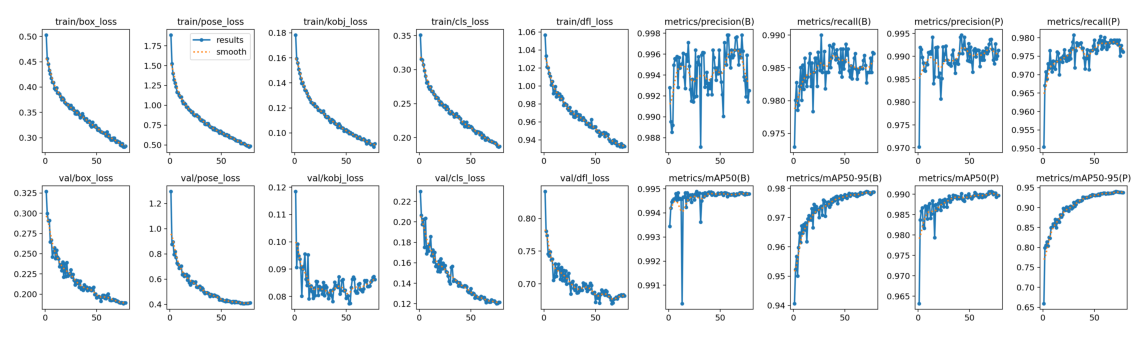

In [ ]:
# Loss and Metrics Graphs
plt.figure(figsize=(12, 8))

img = Image.open(os.path.join(config.project_name, "results.png"))
plt.imshow(img)
plt.tight_layout()
plt.axis("off");

In [ ]:
# Model evaluation on the test set
test_results = model.val(
    data=os.path.join(config.data_dir, "test_data.yaml"),
    name=os.path.join(config.project_name, "test_eval"),
    batch=config.batch_size,
    imgsz=config.imgsz,
    save=True,
    verbose=True,
    exist_ok=True
)

Ultralytics 8.3.192 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.9±11.6 MB/s, size: 142.0 KB)
val: Scanning /content/otp2_dataset/test/labels... 2151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2151/2151 310.0it/s 6.9s
val: New cache created: /content/otp2_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 2.0it/s 1:09
                   all       2151       3872      0.991      0.986      0.995      0.967      0.986      0.975      0.987      0.934
Speed: 0.2ms preprocess, 25.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/drive/MyDrive/Ultralytics/HumanPoseEstimation_YOLO11l_OpenThermalPose2/test_eval


All officially fine-tuned **OpenThermalPose2** models are available in the [official GitHub repository](https://github.com/IS2AI/OpenThermalPose). In this work, the evaluation will also be carried out using the model of interest, **YOLO11l-pose**.

In [ ]:
# Evaluate the official fine-tuned model provided by the authors
!unzip -q /content/drive/MyDrive/otp2_checkpoints.zip
model_ckpt = YOLO(f"/content/otp2_checkpoints/{config.model_name}")

test_results_ckpt = model_ckpt.val(
    data=os.path.join(config.data_dir, "test_data.yaml"),
    batch=config.batch_size,
    imgsz=config.imgsz,
    save=False,
    verbose=True
)

Ultralytics 8.3.192 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1850.4±1097.2 MB/s, size: 192.9 KB)
val: Scanning /content/otp2_dataset/test/labels.cache... 2151 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2151/2151 1216551.8it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 2.0it/s 1:06
                   all       2151       3872       0.99      0.985      0.995       0.97      0.973      0.967      0.976      0.923
Speed: 0.4ms preprocess, 24.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/pose/val


It can be observed that the results obtained in this work are slightly better than the official results across all 8 evaluated metrics, with the performance gap being more pronounced in pose estimation than in detection. The only exception is the $\text{mAP}^{\text{box}}_{50–95}$ metric, where the official result is marginally higher: **0.97** compared to **0.967** achieved in this work.

## **Inference with the Trained Model**

In [10]:
# Load the trained model
model = YOLO(os.path.join(config.project_name, "weights/best.pt"))

In this case, the class implemented for inference with the fine-tuned model is straightforward, since **OpenThermalPose2** shares the same keypoints as **COCO-Pose**. As a result, **Ultralytics** handles almost the entire process, unlike previous pose estimation tasks with other datasets, where all class methods had to be implemented manually.

In [ ]:
class PoseVisualizer():
    """
    Utility class for visualizing YOLO-pose predictions on images and videos. 
    It allows rendering keypoints, skeleton connections, bounding boxes and 
    classes with customizable options.

    Args:
        model (nn.Module): Fine-tuned YOLO-pose model.
        config (Config): Configuration object with paths, hyperparameters, and training options.
    """

    def __init__(self, model, config):
        self.model = model
        self.config = config

    def image_inference(
            self, images, n_rows=2, n_cols=2, random=True, show_boxes=True,
            show_lines=True, show_labels=True, save_path=None
    ):
        """
        Run inference on a set of images and visualize results using Matplotlib.

        Args:
            images (list[str]): List of image paths or image urls.
            n_rows (int, optional): Number of rows in subplot grid..
            n_cols (int, optional): Number of columns in subplot grid.
            random (bool, optional): Whether to sample images randomly.
            show_boxes (bool, optional): Whether to draw bounding boxes.
            show_lines (bool, optional): Whether to draw connection lines between keypoints.
            show_labels (bool, optional): Whether to show class labels.
            save_path (str, optional): Path to save the visualization.
        """
        n_samples = n_rows * n_cols
        samples = np.random.choice(images, n_samples, replace=False).tolist() if random else images[:n_samples]

        # Run YOLO inference
        results = self.model.predict(
            source=samples,
            imgsz=self.config.imgsz,
            batch=self.config.batch_size,
            save=False,
            verbose=False
        )

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.8, n_rows * 4.8))
        axes = axes.flatten() if n_samples > 1 else [axes]

        for i, result in enumerate(results):
            result = result.plot(
                pil=True, font_size=16, line_width=2, kpt_radius=3,
                boxes=show_boxes, kpt_line=show_lines, labels=show_labels
            )
            result = np.array(result)[..., ::-1] # Convert the image to RGB format
            axes[i].imshow(result)
            axes[i].axis("off")

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        plt.show()

    def video_inference(
            self, video, save_path, show=True
    ):
        """
        Run inference on a video and visualize results frame-by-frame using OpenCV.

        Args:
            video (str): Path to input video.
            save_path (str): Path to save processed video (MP4).
            show (bool, optional): Whether to display the output video after processing.
        """
        # Extract video properties
        cap = cv2.VideoCapture(video)
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()

        # Configure temporary video writer
        tmp_path = save_path.replace(".mp4", "_raw.mp4")
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(tmp_path, fourcc, fps, (width, height))

        # Run YOLO inference in streaming mode
        results = self.model.predict(
            source=video,
            imgsz=self.config.imgsz,
            stream=True,
            stream_buffer=True,
            vid_stride=1,
            save=False,
            save_frames=False,
            verbose=False
        )

        for i, result in enumerate(results):
            image = np.array(result.plot())  # frame en BGR
            writer.write(image)

        writer.release()

        # Repackage with ffmpeg for full compatibility
        cmd = [
            "ffmpeg", "-y", "-i", tmp_path,
            "-c:v", "libx264", "-crf", "18", "-preset", "fast",
            "-pix_fmt", "yuv420p", save_path
        ]
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        os.remove(tmp_path)

        # Display predicted video (resized if needed)
        if show:
            max_dim = max(width, height)
            if max_dim > 960:
                height = int(height * (960 / max_dim))
                width = int(width * (960 / max_dim))
            display(Video(save_path, embed=True, width=width, height=height))

In [35]:
visualizer = PoseVisualizer(model, config)

### **Validation Dataset**

In [ ]:
val_image_paths = sorted(glob(os.path.join(config.data_dir, "val/images/*")))

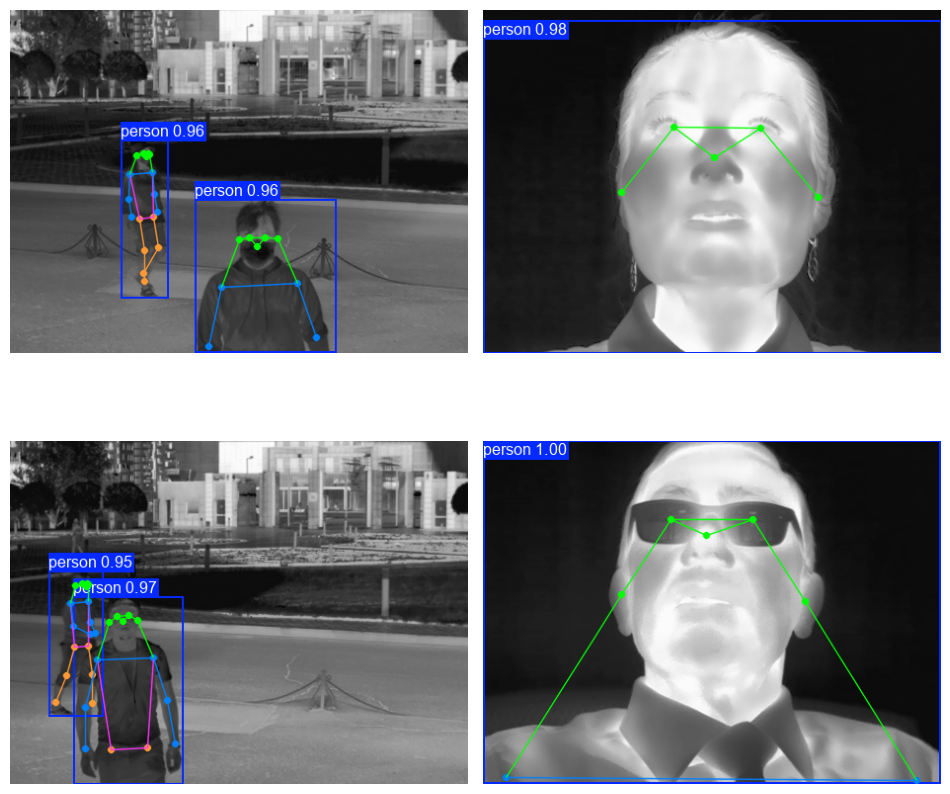

In [ ]:
visualizer.image_inference(val_image_paths, save_path="HumanPoseEstimation_YOLO11l_OpenThermalPose2_1.png")

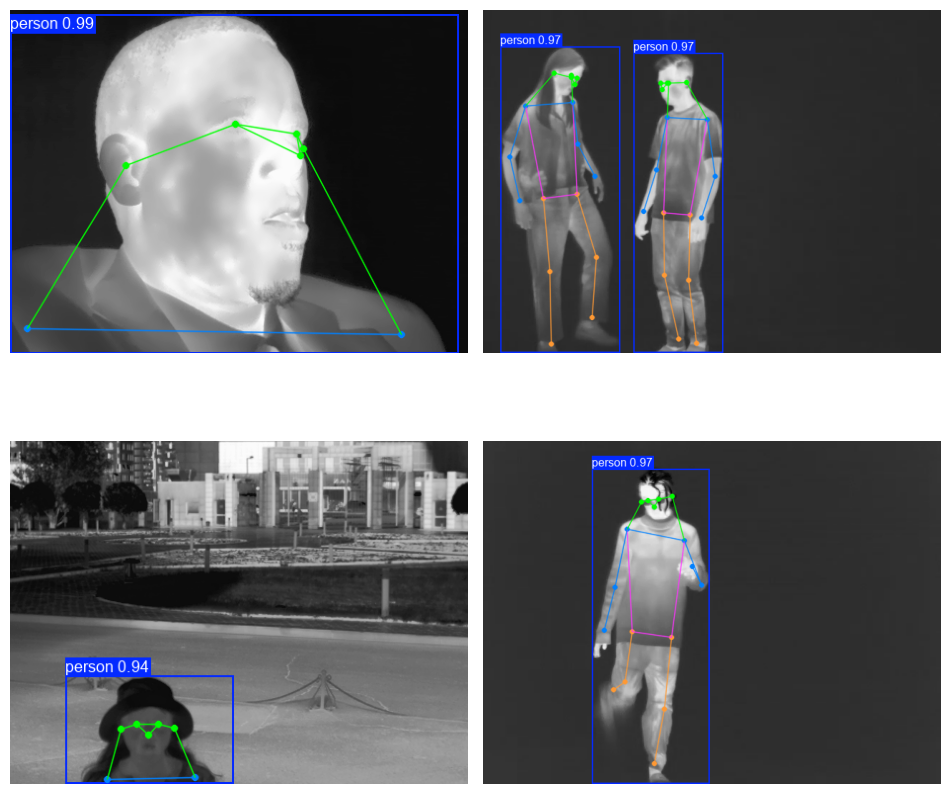

In [ ]:
visualizer.image_inference(val_image_paths)

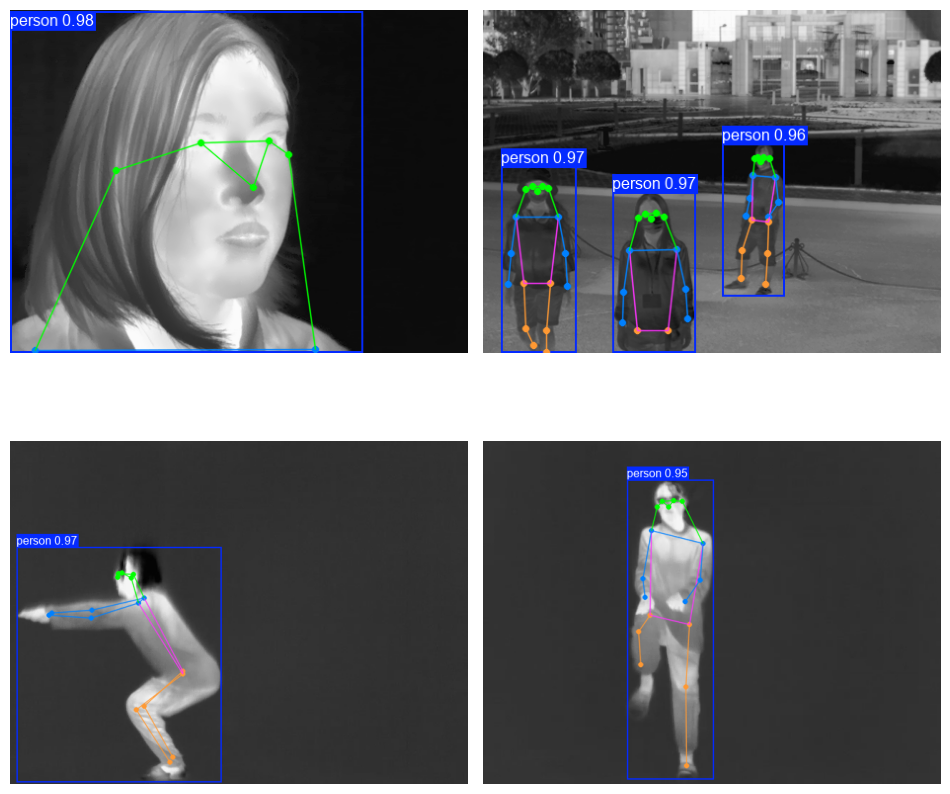

In [ ]:
visualizer.image_inference(val_image_paths)

### **Test Dataset**

In [ ]:
test_image_paths = sorted(glob(os.path.join(config.data_dir, "test/images/*")))

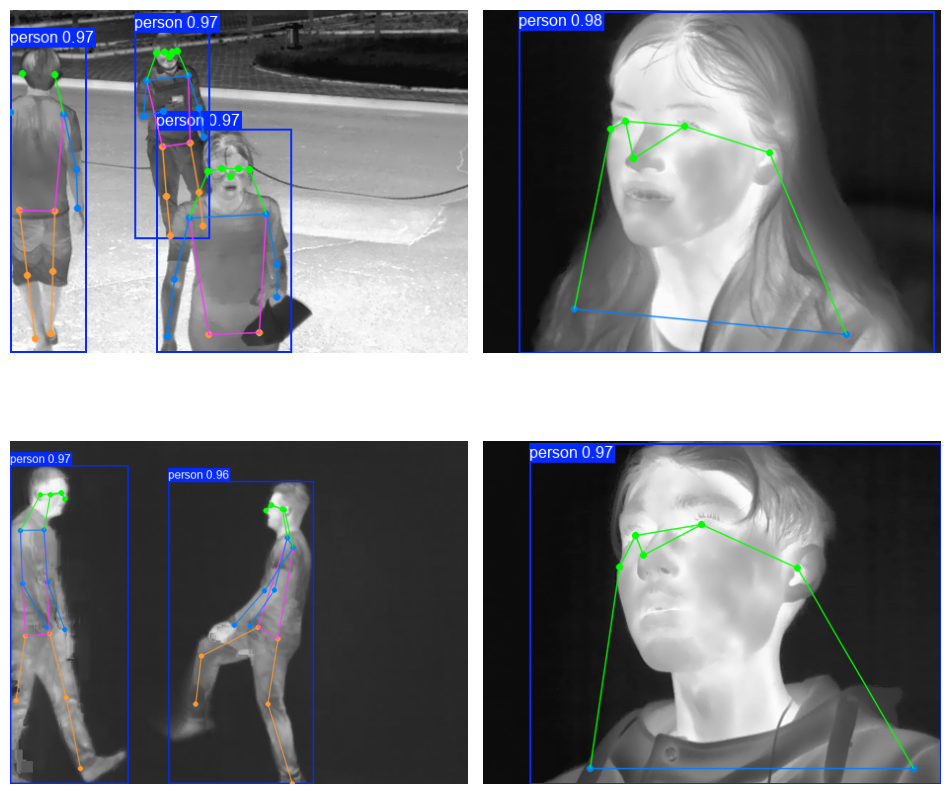

In [ ]:
visualizer.image_inference(test_image_paths, save_path="HumanPoseEstimation_YOLO11l_OpenThermalPose2_2.png")

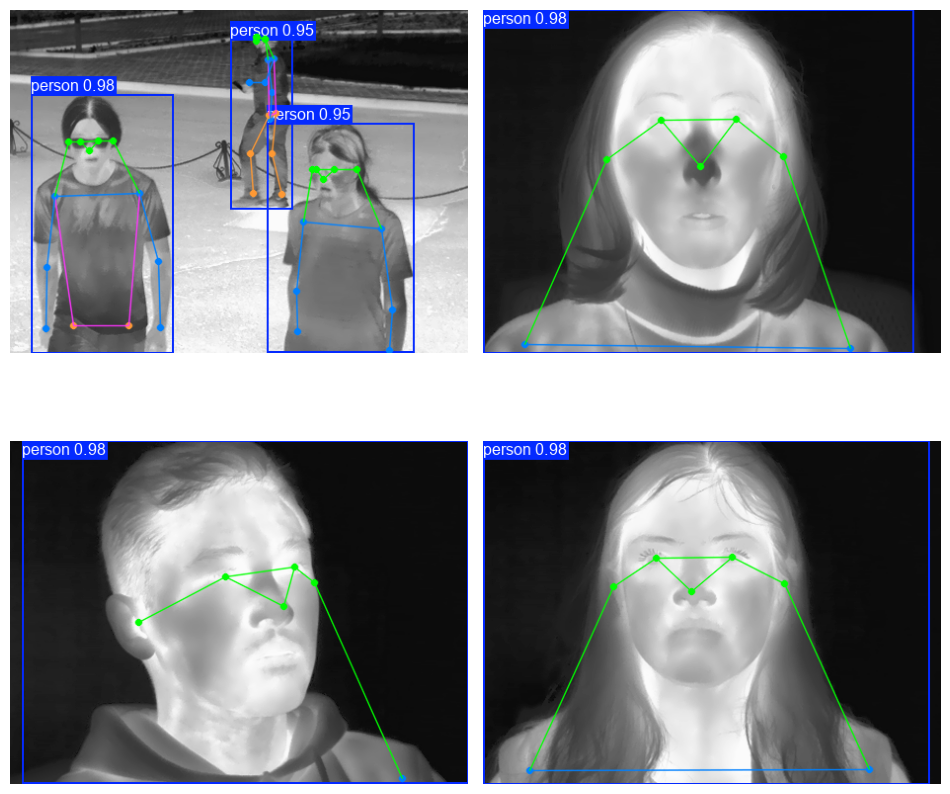

In [ ]:
visualizer.image_inference(test_image_paths)

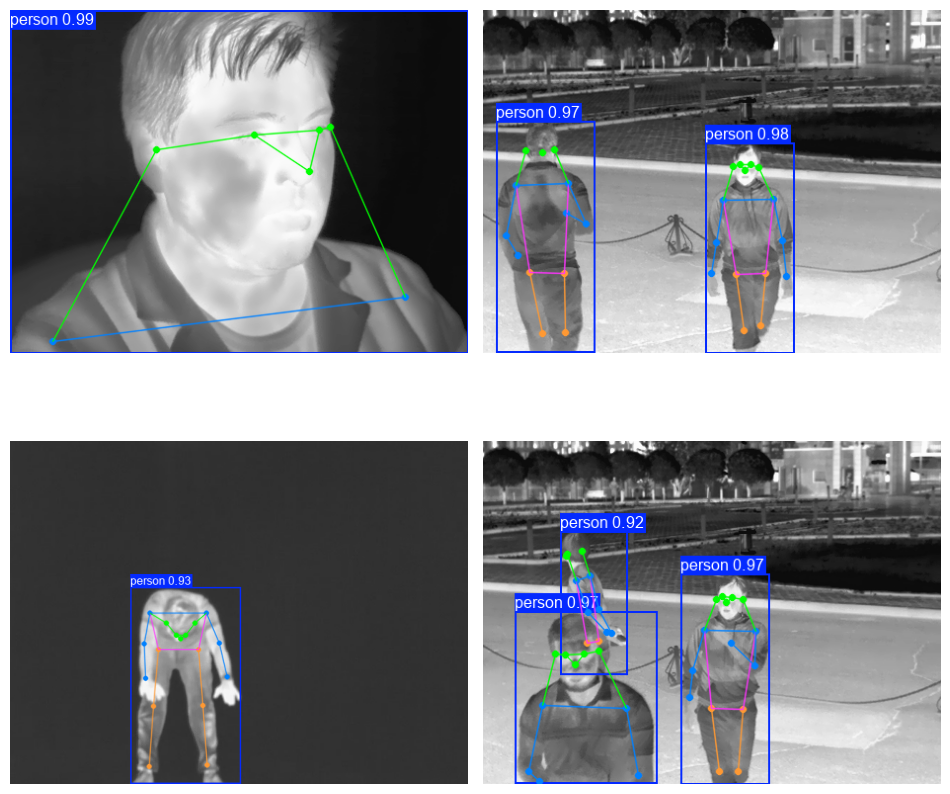

In [ ]:
visualizer.image_inference(test_image_paths)

### **Internet Images**

In [ ]:
list_urls = [
    "https://lindaalterwitz.com/wp-content/uploads/2023/11/03_laura-800x600.jpg",
    "https://i.pinimg.com/736x/76/2d/fb/762dfb2f148e08b5b3356f86e426ed71.jpg",
    "https://img.securityinfowatch.com/files/base/cygnus/siw/image/2017/11/Thermal_Man_in_bushes_png.5a1c44f53d125.png?auto=format,compress&fit=fill&fill=blur&q=45&w=640&width=640",
    "https://www.vvdntech.com/en-us/images/thermal-camera-design-target-app1.jpg"
]

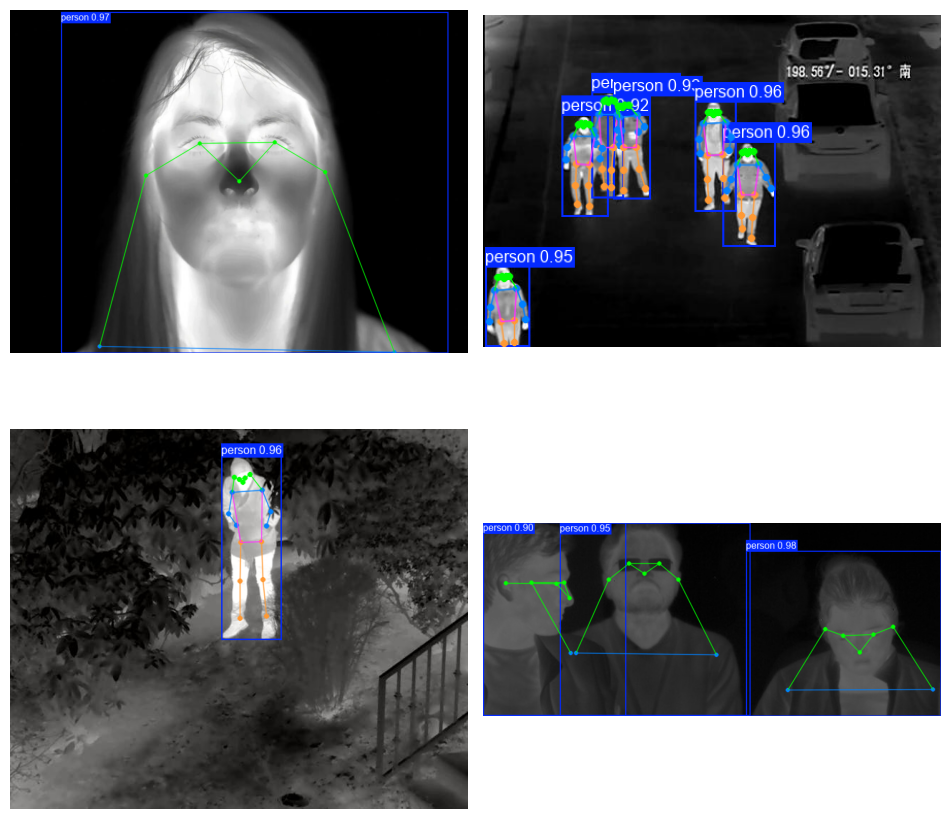

In [ ]:
visualizer.image_inference(
    list_urls, random=False,
    save_path="HumanPoseEstimation_YOLO11l_OpenThermalPose2_3.png"
)

### **Video Inference**

The video used for inference is an excerpt from the following [YouTube video](https://youtu.be/tZ5Mu2gs-M8).

In [37]:
video_urls = [
    "/content/drive/MyDrive/Videos/OpenThermalPose2.mp4",
]

In [3]:
visualizer.video_inference(video_urls[0], "HumanPoseEstimation_YOLO11l_OpenThermalPose2.mp4")

## **Conclusion**

The **YOLO11l-pose** model fine-tuned on the **OpenThermalPose2** dataset achieved outstanding results in both pose estimation and detection. In several metrics, the performance is remarkably close to perfection on both the validation and test sets. On the validation set, the model reached a $\text{mAP}^{\text{box}}_{50}$ of **0.995**, a $\text{mAP}^{\text{box}}_{50–95}$ of **0.979**, a $\text{mAP}^{\text{pose}}_{50}$ of **0.991**, and a $\text{mAP}^{\text{pose}}_{50–95}$ of **0.94**. On the test set, it achieved a $\text{mAP}^{\text{box}}_{50}$ of **0.995**, a $\text{mAP}^{\text{box}}_{50–95}$ of **0.967**, a $\text{mAP}^{\text{pose}}_{50}$ of **0.987**, and a $\text{mAP}^{\text{pose}}_{50–95}$ of **0.934**.

Although these results demonstrate excellent performance, further improvements could be achieved by enhancing the model's robustness in more complex and general scenarios, such as crowded scenes with high person density per image, different imaging modalities (RGB, color thermal, or grayscale thermal), and challenging environmental conditions. Achieving this would require extending the dataset with images that incorporate these characteristics, ultimately leading to a more advanced model suitable for highly demanding applications.

Nevertheless, the fine-tuned model already delivers exceptional performance in real-world applications with grayscale thermal images or videos, making it highly suitable for fields such as surveillance, security, and automated monitoring.